In [59]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
import ast

import cassiopeia as cas
import matplotlib.pyplot as plt
import mplscience
import numpy as np
import pandas as pd
import pickle as pic
import scanpy as sc
import seaborn as sns
import squidpy as sq
import tqdm

SPATIAL_PACKAGE="/path/to/spatial/package/"
DATA_DIR="/path/to/spatial/dataset/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import spatial_utilities, target_site_utilities, tree_utilities

In [53]:
indel_priors = pd.read_csv(f"{SPATIAL_PACKAGE}/data/allele_priors.tsv", sep='\t', index_col = 0)
indel_colors = cas.pl.utilities.get_indel_colors(indel_priors, np.random.RandomState(1234))

In [2]:
def cut_at_depth(tree, depth=1):

    # assign depths
    tree.set_attribute(tree.root, 'depth', 0)

    for n in tree.depth_first_traverse_nodes(tree.root, postorder=False):
        if n == tree.root:
            continue

        parent = tree.parent(n)
        parent_depth = tree.get_attribute(parent, 'depth')
        tree.set_attribute(n, 'depth', parent_depth+1)
        
    # get nodes at specified depth 
    nodes_to_cut = [n for n in tree.nodes if tree.get_attribute(n, 'depth') == depth]

    clusters = {}
    for i, n in zip(range(len(nodes_to_cut)), nodes_to_cut):
        for leaf in tree.leaves_in_subtree(n):
        
            clusters[leaf] = f'cluster_{i+1}'

    return clusters    

### Extended Data Figure 2e

In [35]:
SLIDETAGS_SAMPLES = [('Layer1', 'Puck1'),
           ('Layer2', 'Puck1'),
           ('Layer3', 'Puck1'),
           ('Layer3', 'Puck2'),
           ('Layer4', 'Puck1')]

In [36]:
LAYER, PUCK = SLIDETAGS_SAMPLES[2]

adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/adata_slidetags.{LAYER}.{PUCK}.h5ad')
adata_raw = adata.raw.to_adata()

adata_raw.var_names = adata_raw.var_names.astype('str')
adata_raw.var_names_make_unique()

n_cells = adata.n_obs
mean_rna = adata.obs["total_counts"].mean()
print(
        f"Detected {n_cells} spots. Detected a mean UMI count of {mean_rna}."
    )

tree = pic.load(open(f'{DATA_DIR}/slidetags/trees/{PUCK}_{LAYER}_hybrid.pkl', 'rb'))
state_to_indel = pic.load(open(f'{DATA_DIR}/slidetags/trees/{PUCK}_{LAYER}_state2indel.pkl', 'rb'))

# clean up and collapse edges
tree = tree_utilities.cleanup_character_matrix_and_collapse(tree)

character_matrix_to_plot = tree.character_matrix.copy()


Detected 7253 spots. Detected a mean UMI count of 4294.932579622226.
Cleaned up 0 ambiguous characters.


In [51]:
output_directory = f'./data/slidetags_infercnv/'

# load in CNV data
df_regions = pd.read_csv(f'{output_directory}/{LAYER}_{PUCK}_HMM_CNV_predictions.HMMi6.leiden.hmm_mode-subclusters.Pnorm_0.2.pred_cnv_regions.dat', sep='\t')
df_cells = pd.read_csv(f'{output_directory}/{LAYER}_{PUCK}_infercnv.observation_groupings.txt', sep=' ')
df_cells['cell_group_name'] = df_cells.apply(lambda x: f'{x["Dendrogram Group"].split("_")[0]}.{x["Dendrogram Group"]}', axis=1)
df_cells['cell'] = df_cells.index

df_merged = pd.merge(df_regions, df_cells[~df_cells['cell_group_name'].str.contains('Normal')], on='cell_group_name')

_cnv_counts = pd.DataFrame(pd.merge(df_regions, df_cells, on='cell_group_name')[['cell', 'cnv_name', 'cell_group_name']].groupby('cell').size())

cnv_counts = pd.DataFrame([0]*len(tree.leaves), index=tree.leaves, columns = ['cnv_count'])
cnv_counts.loc[np.intersect1d(tree.leaves, _cnv_counts.index), 'cnv_count'] = _cnv_counts.loc[np.intersect1d(tree.leaves, _cnv_counts.index), 0]


cnv_counts = cnv_counts.loc[np.intersect1d(tree.leaves, cnv_counts.index)]

infercnv_groupings = pd.read_csv(f'{output_directory}/{LAYER}_{PUCK}_infercnv.observation_groupings.txt', sep=' ')
infercnv_groupings['cell_group_name'] = infercnv_groupings.apply(lambda x: f'{x["Dendrogram Group"]}', axis=1)

infercnv_tree = cas.data.CassiopeiaTree(tree=f'{output_directory}/{LAYER}_{PUCK}_infercnv.observations_dendrogram.txt')

infercnv_groupings.head(5)

,Dendrogram Group,Dendrogram Color,Annotation Group,Annotation Color,cell_group_name
L6.GGTGTTACAAGAAATC,Tumor-0_s7,#8DD3C7,1,#8DD3C7,Tumor-0_s7
L5.TTACGCCTCCTCACTG,Tumor-0_s6,#F0EFBB,1,#8DD3C7,Tumor-0_s6
L6.TTCATGTTCACGACTA,Tumor-0_s6,#F0EFBB,1,#8DD3C7,Tumor-0_s6
L5.AGGCTGCTCTGCCCTA,Tumor-0_s5,#D9A0AB,1,#8DD3C7,Tumor-0_s5
L6.AATTTCCTCTGTACAG,Tumor-0_s5,#D9A0AB,1,#8DD3C7,Tumor-0_s5


In [38]:
infercnv_groupings['cell_group_name2'] = infercnv_groupings.apply(lambda x: 'Normal' if 'Normal' in x.cell_group_name else '.'.join(x.cell_group_name.split(".")[:4]), axis=1)
grouping_counts = infercnv_groupings['cell_group_name2'].value_counts()

filter_groups = grouping_counts[grouping_counts  < 20].index.values

infercnv_groupings.loc[infercnv_groupings['cell_group_name2'].isin(filter_groups), 'cell_group_name2'] = np.nan

infercnv_groupings['cell_group_name2'].value_counts()

cell_group_name2
Tumor-0_s1    2264
Tumor-1_s1    1525
Tumor-0_s2     887
Tumor-1_s2     826
Tumor-2_s1     653
Name: count, dtype: int64

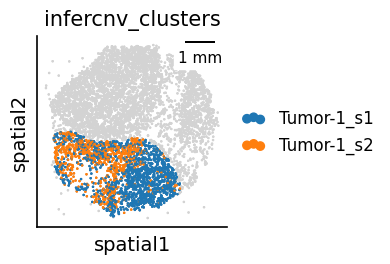

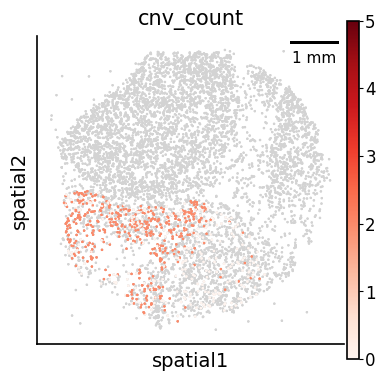

In [39]:
adata.obs['infercnv_clusters'] = None
adata.obs['cnv_count'] = None

adata.obs.loc[infercnv_groupings.index.astype(str), 'infercnv_clusters'] = infercnv_groupings['cell_group_name2'].values
adata.obs.loc[cnv_counts.index, 'cnv_count'] = cnv_counts['cnv_count'].values

with mplscience.style_context():
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata, size=2, shape=None, na_color='lightgray', ax=ax, figsize=(4,4), legend_loc=None)
    sq.pl.spatial_scatter(adata[adata.obs['tumor_id'] == 'Tumor-1'], color=['infercnv_clusters'],
                          groups = [cluster for cluster in adata.obs['infercnv_clusters'].unique() if 'non-tumor' not in str(cluster)],
                          size=2, ax=ax, shape=None,
                          scalebar_dx=1.0,
                            scalebar_units='um',
                            scalebar_kwargs={"scale_loc": "bottom", "location": "upper right"},
                         )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata, size=2, shape=None, na_color='lightgray', ax=ax, figsize=(4,4), legend_loc=None)
    sq.pl.spatial_scatter(adata[adata.obs['tumor_id'] == 'Tumor-1'], color=['cnv_count'],
                          cmap='Reds',
                          size=2, ax=ax, shape=None,
                          scalebar_dx=1.0,
                          vmax=5,
                        scalebar_units='um',
                        scalebar_kwargs={"scale_loc": "bottom", "location": "upper right"},
                         )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [44]:
tree.cell_meta = pd.DataFrame(index=tree.leaves)
tree.cell_meta['infercnv_clusters'] = None
tree.cell_meta['cnv_count'] = 0

overlapping = np.intersect1d(tree.leaves, infercnv_groupings.index)
tree.cell_meta.loc[overlapping, 'infercnv_clusters'] = infercnv_groupings.loc[overlapping, 'cell_group_name2'].astype(str)

tree.cell_meta['infercnv_clusters'].fillna(value='None', inplace=True)

tree.cell_meta.loc[cnv_counts.index, 'cnv_count'] = np.log2(1+cnv_counts['cnv_count'])

tree.cell_meta['tracer_counts'] = np.log2(1+tree.character_matrix.apply(lambda x: len(x[(x != -1) & (x != 0)]), axis=1))
tree.cell_meta['tumor_id'] = adata.obs.loc[tree.leaves, 'tumor_id']

infercnv_tree.cell_meta = pd.DataFrame(index=infercnv_tree.leaves)
infercnv_tree.cell_meta['tumor_id'] = adata.obs.loc[infercnv_tree.cell_meta.index, 'tumor_id']

In [45]:
tree.cell_meta.groupby(['tumor_id'])['tracer_counts'].max()

tumor_id
Tumor-1      4.754888
Tumor-2      4.807355
Tumor-3      4.754888
non-tumor    4.754888
Name: tracer_counts, dtype: float64

                    infercnv_clusters  cnv_count  tracer_counts tumor_id
L5.ACTATGGCATAACAGA        Tumor-1_s1        0.0       4.169925  Tumor-1
L6.GATCCCTAGCCTGACC        Tumor-1_s1        0.0       3.906891  Tumor-1
L5.CAACAGTTCATCGCCT        Tumor-1_s1        0.0       3.906891  Tumor-1
L6.GAATCGTGTTAACAGA        Tumor-1_s1        0.0       3.807355  Tumor-1
L6.ACACGCGCAGGATTCT        Tumor-1_s1        0.0       3.700440  Tumor-1
                    infercnv_clusters  cnv_count  tracer_counts tumor_id
L5.CGAATTGAGTATGATG        Tumor-0_s1        0.0       3.906891  Tumor-2
L6.CAATTTCGTTACGTAC        Tumor-0_s1        0.0       3.584963  Tumor-2
L5.GGAGGTAGTCTGCCTT        Tumor-0_s2        0.0       4.169925  Tumor-2
L6.ACTTCGCTCATGCGGC        Tumor-0_s1        0.0       4.169925  Tumor-2
L6.TTGGGTATCAAGTCGT        Tumor-0_s1        0.0       3.321928  Tumor-2
                    infercnv_clusters  cnv_count  tracer_counts tumor_id
L5.AATCACGTCACCTTGC        Tumor-2_s1        0.0   

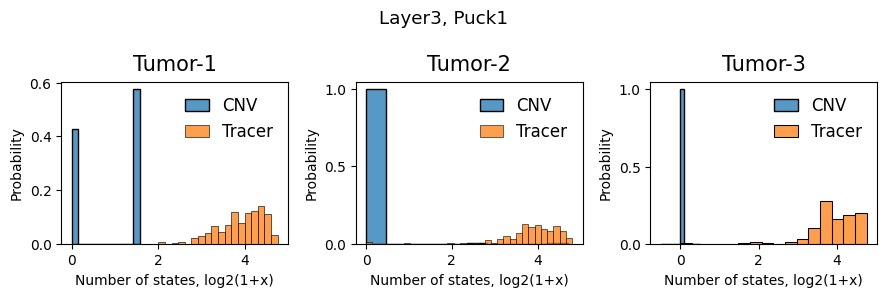

In [46]:
## Plot distribution of indels vs CNVs

num_tumors = len([x for x in tree.cell_meta['tumor_id'].unique() if x != 'non-tumor'])

fig, axes = plt.subplots(1, num_tumors, figsize=(9, 3))

with mplscience.style_context():

    for i in range(len(axes)):   

        tumor_id = f'Tumor-{i+1}'
        sub_meta = tree.cell_meta[tree.cell_meta['tumor_id'] == tumor_id]

        print(sub_meta.head(5))
        
        sns.histplot(sub_meta['cnv_count'], label='CNV', fill=True, ax=axes[i], stat='probability', bins=10)
        sns.histplot(sub_meta['tracer_counts'], label='Tracer', fill=True, ax=axes[i], stat='probability')
        axes[i].set_title(f'Tumor-{i+1}')
        axes[i].legend()
        axes[i].set_xlabel('Number of states, log2(1+x)')

    fig.suptitle(f'{LAYER}, {PUCK}')
    plt.tight_layout()
    plt.show()

In [47]:
def get_subtree(_tree, tumor):

    query_cells = list(adata[adata.obs['tumor_id'] == FOCUS_TUMOR,:].obs_names)
    overlapping_cells = np.intersect1d(_tree.leaves, query_cells)
    to_remove = np.setdiff1d(_tree.leaves, overlapping_cells)
    
    subtree = _tree.copy()
    subtree.remove_leaves_and_prune_lineages(to_remove)

    return subtree
    

FOCUS_TUMOR = 'Tumor-1'
subtree = get_subtree(tree, FOCUS_TUMOR)
subtree_infercnv = get_subtree(infercnv_tree, FOCUS_TUMOR)


  0%|          | 0/1642 [00:00<?, ?it/s]

filling in multiindex table:   0%|          | 0/29385 [00:00<?, ?it/s]

100%|██████████| 27/27 [00:00<00:00, 59.73it/s]


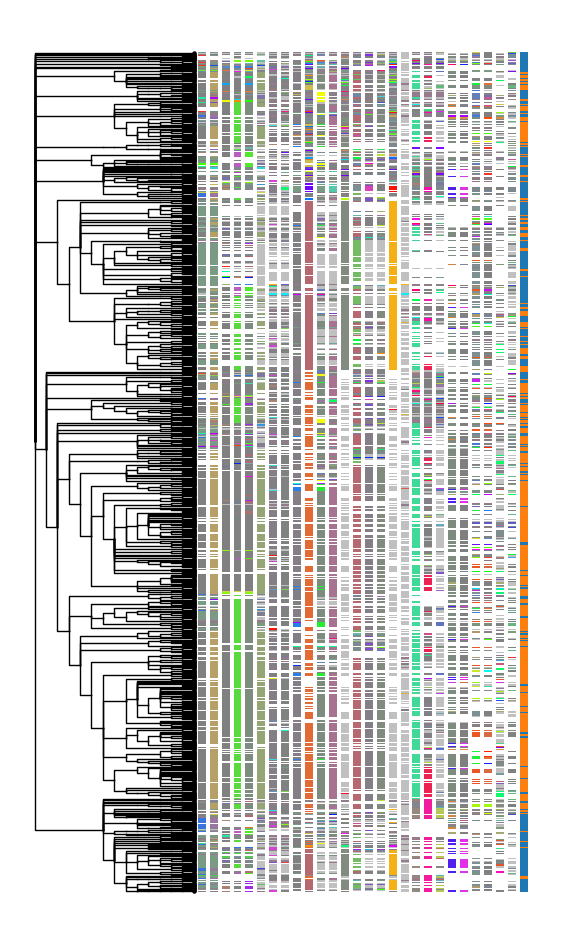

In [55]:
allele_table = tree_utilities.character_matrix_to_allele_table(character_matrix_to_plot, state_to_indel, keep_ambiguous=False)

percent_present = allele_table.groupby('intBC').agg({'r1': len}) / allele_table['cellBC'].nunique()
to_keep = percent_present[(percent_present.values > 0.05)].index

allele_table_filtered = allele_table[allele_table['intBC'].isin(to_keep)]
allele_table_filtered['intBC'].unique()

h = plt.figure(figsize=(7,12))
ax = plt.gca()
cas.pl.plot_matplotlib(
    subtree,
    orient='right',
    allele_table=allele_table_filtered,
    add_root=False,
    indel_colors=indel_colors,
    indel_priors=indel_priors,
    meta_data = ['infercnv_clusters'],
    figsize=(7, 12),
    ax=ax,
)

plt.show()

## Extended Data Figure 3c

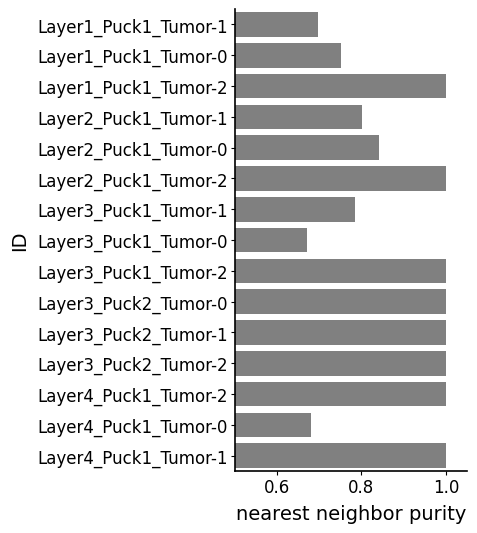

In [58]:
all_nn_scores = pd.read_csv("./data/slidetags_infercnv_nn_score.tsv", sep='\t')

all_nn_scores['ID'] = all_nn_scores.apply(lambda x: f'{x.Layer}_{x.Puck}_{x.Tumor}', axis=1)
all_nn_scores.index = all_nn_scores['ID']
_order = ['Layer1_Puck1_Tumor-1', 'Layer1_Puck1_Tumor-0', 'Layer1_Puck1_Tumor-2',
         'Layer2_Puck1_Tumor-1', 'Layer2_Puck1_Tumor-0', 'Layer2_Puck1_Tumor-2',
         'Layer3_Puck1_Tumor-1', 'Layer3_Puck1_Tumor-0', 'Layer3_Puck1_Tumor-2',
         'Layer3_Puck2_Tumor-0', 'Layer3_Puck2_Tumor-1', 'Layer3_Puck2_Tumor-2',
         'Layer4_Puck1_Tumor-2', 'Layer4_Puck1_Tumor-0', 'Layer4_Puck1_Tumor-1']


with mplscience.style_context():

    fig = plt.figure(figsize=(3, 6))
    sns.barplot(all_nn_scores.loc[_order,:], x='NN_score', y='ID', linewidth=1, color='gray')
    plt.xlim(0.5, 1.05)
    plt.xlabel("nearest neighbor purity")
    plt.show()